In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 96.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=d120aa8ad5242093f766b6614c40ebaca229657c72a48c155ef21434ee9cdc63
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


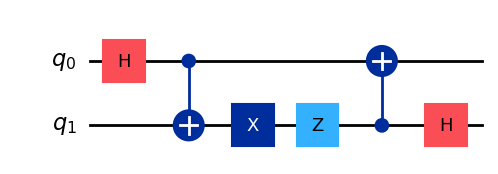

In [2]:
# Superdense coding

# The classical 2-bit value is encoded by applying X and/or Z gates

sdc = QuantumCircuit(2)

# qubits 0 and 1 are the shared entangled state
# Alice has qubit 1, Bob has qubit 0

# Entangle qubits 0 and 1
sdc.h(0)
sdc.cx(0,1)

# Encoding by Alice, working on qubit 1
# For each of 00, 01, 10, 11, there is a block of code that can be commented or uncommented.

# For 00, do nothing

# For 01, apply X to qubit 1
#sdc.x(1)

# For 10, apply Z to qubit 1
#sdc.z(1)

# For 11, apply X then Z to qubit 1
sdc.x(1)
sdc.z(1)

# Decoding by Bob, working on qubits 0 and 1

sdc.cx(1,0)
sdc.h(1)

sdc.draw("mpl")

In [3]:
state = Statevector.from_int(0, 4)  # 4 basis states on 2 qubits

# Apply the circuit to the state
state = state.evolve(sdc)

# Display using latex.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

/usr/local/lib/python3.12/dist-packages/qiskit_aer/noise/noise_model.py:378: UserWarning: Qiskit backend <qiskit.providers.fake_provider.generic_backend_v2.GenericBackendV2 object at 0x7b9e2b61c650> has no QubitProperties, so the resulting noise model will not include any thermal relaxation errors.
  warn(


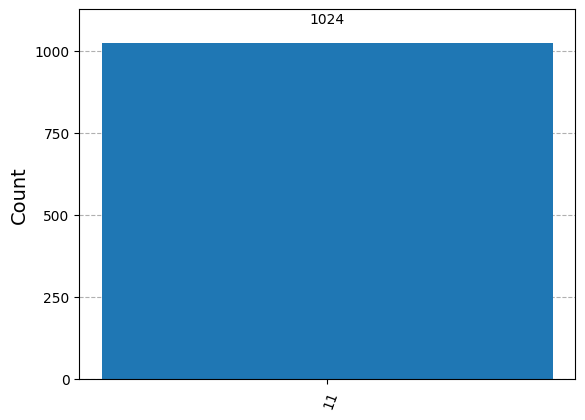

In [4]:
# EXERCISE

# Instead of calculating the state and displaying it, try simulating the circuit
# in a similar way to previous exercises. You will need to add some measurements
# so that you can check that the measurement statistics match the value that Alice
# encoded.

sdc_sim = QuantumCircuit(2, 2)
# Entangle
sdc_sim.h(0)
sdc_sim.cx(0, 1)

# Alice's encoding — change this block to test different messages
# 00: do nothing
# 01: sdc_sim.x(1)
# 10: sdc_sim.z(1)
# 11:
sdc_sim.x(1)
sdc_sim.z(1)

# Bob's decoding
sdc_sim.cx(1, 0)
sdc_sim.h(1)

# Measure both qubits
sdc_sim.measure([0, 1], [0, 1])

# Simulate
backend = GenericBackendV2(num_qubits=2, control_flow=True, noise_info=False)
compiled = transpile(sdc_sim, backend)
job = backend.run(compiled, shots=1024)
counts = job.result().get_counts(compiled)
plot_histogram(counts)

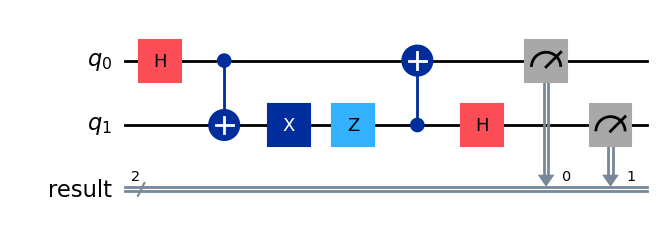

In [5]:
# EXERCISE

# A better implementation of superdense coding uses two classical bits as inputs,
# and the conditional operators that we saw in Lab-2B. Encoding the two-bit
# classical value is similar to the last stage of teleportation, where the measurement
# results are used to adjust Bob's qubit.

# Implement superdense coding this way.
from qiskit.circuit import ClassicalRegister, QuantumRegister

# Alice's message — change this to '00', '01', '10', or '11'
alice_message = '11'

qr = QuantumRegister(2, 'q')
cr_result = ClassicalRegister(2, 'result')
sdc_dynamic = QuantumCircuit(qr, cr_result)

# Entangle qubits
sdc_dynamic.h(qr[0])
sdc_dynamic.cx(qr[0], qr[1])

# Alice's encoding based on her 2-bit message
# alice_message[1] is the first bit, alice_message[0] is the second bit
if alice_message[1] == '1':
    sdc_dynamic.x(qr[1])   # Apply X if first bit is 1
if alice_message[0] == '1':
    sdc_dynamic.z(qr[1])   # Apply Z if second bit is 1

# Bob's decoding
sdc_dynamic.cx(qr[1], qr[0])
sdc_dynamic.h(qr[1])

# Measure
sdc_dynamic.measure(qr[0], cr_result[0])
sdc_dynamic.measure(qr[1], cr_result[1])

sdc_dynamic.draw("mpl")



/usr/local/lib/python3.12/dist-packages/qiskit_aer/noise/noise_model.py:378: UserWarning: Qiskit backend <qiskit.providers.fake_provider.generic_backend_v2.GenericBackendV2 object at 0x7b9e2adcac60> has no QubitProperties, so the resulting noise model will not include any thermal relaxation errors.
  warn(


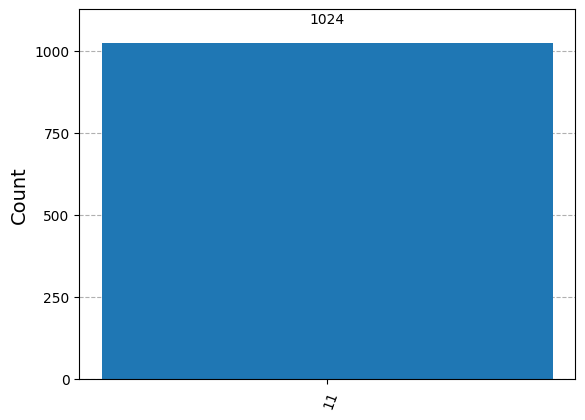

In [6]:
backend = GenericBackendV2(num_qubits=2, control_flow=True, noise_info=False)
compiled = transpile(sdc_dynamic, backend)
job = backend.run(compiled, shots=1024)
counts = job.result().get_counts(compiled)
plot_histogram(counts)